# Exp03 Location Ablation Only

- 모델: AdaFace IR101 WebFace12M
- 입력: Color LFW, funneled=True
- 위치: forehead, nose_bridge, right_cheek, chin, right_under_eye
- 크기: patch_size_ratio=0.30 고정
- 다음 Exp04에서 쓸 best location을 `03_best_location.json`으로 저장한다.

In [1]:
# ============================================================
# Cell 0. Dependency Installation
# ============================================================
INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    !pip -q uninstall -y transformers tokenizers huggingface_hub facenet-pytorch
    !pip -q install \
        "transformers==4.45.2" \
        "tokenizers>=0.20,<0.21" \
        "huggingface_hub>=0.23.2" \
        "safetensors" \
        "omegaconf" \
        "timm" \
        "fvcore" \
        "scikit-learn" \
        "matplotlib" \
        "pandas" \
        "tqdm"
    !pip -q install facenet-pytorch --no-deps


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 135.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 86.3 MB/s eta 0:00:00


In [2]:
# ============================================================
# Cell 1. Imports and Config
# ============================================================
import os, sys, json, math, random
from pathlib import Path
from collections import defaultdict
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF

from sklearn.datasets import fetch_lfw_people
from huggingface_hub import snapshot_download
from transformers import AutoModel
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

# ------------------------------------------------------------
# Model / dataset setting
# ------------------------------------------------------------
MODEL_NAME = 'minchul/cvlface_adaface_ir101_webface12m'
MODEL_SHORT_NAME = 'adaface_ir101_wf12m'

NUM_IDENTITIES = 100
MIN_FACES_PER_PERSON = 5
ENROLL_IMAGES_PER_ID = 1
MAX_PROBES_PER_ID = 8
TARGET_FAR = 0.01

BATCH_SIZE = 64
NUM_WORKERS = 0

# ------------------------------------------------------------
# Exp03 setting
# ------------------------------------------------------------
DRIVE_ROOT = Path('/content/drive/MyDrive')
MASCOT_PATH = DRIVE_ROOT / 'SafeAI-final-project/mask/puang.png'

EXP03_LOCATIONS = [
    'forehead',
    'nose_bridge',
    'right_cheek',
    'chin',
    'right_under_eye',
]
EXP03_PATCH_SIZE_RATIO = 0.30

ATTACK_STEPS = 1000
ATTACK_BATCH_SIZE = 32
ATTACK_LR = 0.05

TAU = 0.05
MARGIN = 0.05
THRESHOLD_MARGIN = 0.00
LAMBDA_TRUE = 1.0
LAMBDA_IMP = 2.0
LAMBDA_THRESH = 2.0
LAMBDA_RANK = 1.0
TV_WEIGHT = 0.0

USE_LANDMARK_BASED_PLACEMENT = True
LANDMARK_FALLBACK_TO_CANONICAL = True
CANONICAL_LANDMARKS_112 = np.array([
    [38.0, 42.0],
    [74.0, 42.0],
    [56.0, 60.0],
    [42.0, 78.0],
    [70.0, 78.0],
], dtype=np.float32)

# ------------------------------------------------------------
# Output path: exp03 전용 run 폴더
# ------------------------------------------------------------
RUN_TAG = datetime.now(ZoneInfo('Asia/Seoul')).strftime('run_%Y%m%d_%H%M%S')
PROJECT_DRIVE_DIR = DRIVE_ROOT / 'SafeAI-final-project' / 'output'
RUN_ROOT = PROJECT_DRIVE_DIR / 'exp03_location_ablation_only_color_lfw' / MODEL_SHORT_NAME / RUN_TAG

PREREQ_DIR = RUN_ROOT / 'prereq_clean_baseline'
PROCESS_DIR = RUN_ROOT / 'process_visuals'
EXP03_DIR = RUN_ROOT / 'exp03_location_ablation'
EXP03_DETAIL_DIR = EXP03_DIR / 'details'
EXP03_FIG_DIR = EXP03_DIR / 'figures'
EXP03_PATCH_DIR = EXP03_DIR / 'patches'
EXP03_HISTORY_DIR = EXP03_DIR / 'histories'

for d in [RUN_ROOT, PREREQ_DIR, PROCESS_DIR, EXP03_DIR, EXP03_DETAIL_DIR, EXP03_FIG_DIR, EXP03_PATCH_DIR, EXP03_HISTORY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('RUN_TAG:', RUN_TAG)
print('RUN_ROOT:', RUN_ROOT)

if not Path(MASCOT_PATH).exists():
    raise FileNotFoundError(f'MASCOT_PATH가 존재하지 않음: {MASCOT_PATH}')


Mounted at /content/drive
DEVICE: cuda
RUN_TAG: run_20260615_122035
RUN_ROOT: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035


In [3]:
# ============================================================
# Cell 2. Image / Plot Utilities
# ============================================================
preprocess = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

def numpy_face_to_pil(img):
    img = np.asarray(img)
    if img.ndim == 3 and img.shape[0] in [1, 3] and img.shape[-1] not in [1, 3]:
        img = np.transpose(img, (1, 2, 0))
    if np.issubdtype(img.dtype, np.floating):
        img = np.nan_to_num(img)
        if img.max() <= 1.5:
            img = img * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)
    else:
        img = np.clip(img, 0, 255).astype(np.uint8)
    if img.ndim == 2:
        return Image.fromarray(img, mode='L').convert('RGB')
    return Image.fromarray(img).convert('RGB')

def pil_to_model_tensor(pil):
    return preprocess(pil.convert('RGB'))

def tensor_to_pil(x):
    x = x.detach().cpu().clamp(-1, 1)
    x = (x * 0.5 + 0.5).clamp(0, 1)
    return TF.to_pil_image(x)

def show_pil_grid(images, titles=None, ncols=5, figsize=(12, 6), save_path=None):
    n = len(images)
    if n == 0:
        print('No images to show.')
        return
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(img)
        ax.axis('off')
        if titles is not None:
            ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches='tight')
        print('Saved:', save_path)
    plt.show()

def save_patch_png(patch, mask, path):
    patch = patch.detach().cpu().clamp(-1, 1)
    mask = mask.detach().cpu().clamp(0, 1)
    rgb = (patch[0] * 0.5 + 0.5).clamp(0, 1)
    alpha = mask[0].clamp(0, 1)
    rgba = torch.cat([rgb, alpha], dim=0)
    pil = TF.to_pil_image(rgba)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pil.save(path)
    print('Saved:', path)


Enrollment images: 100
Probe images: 629
Identities: 100
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/process_visuals/00_raw_color_lfw_samples.png


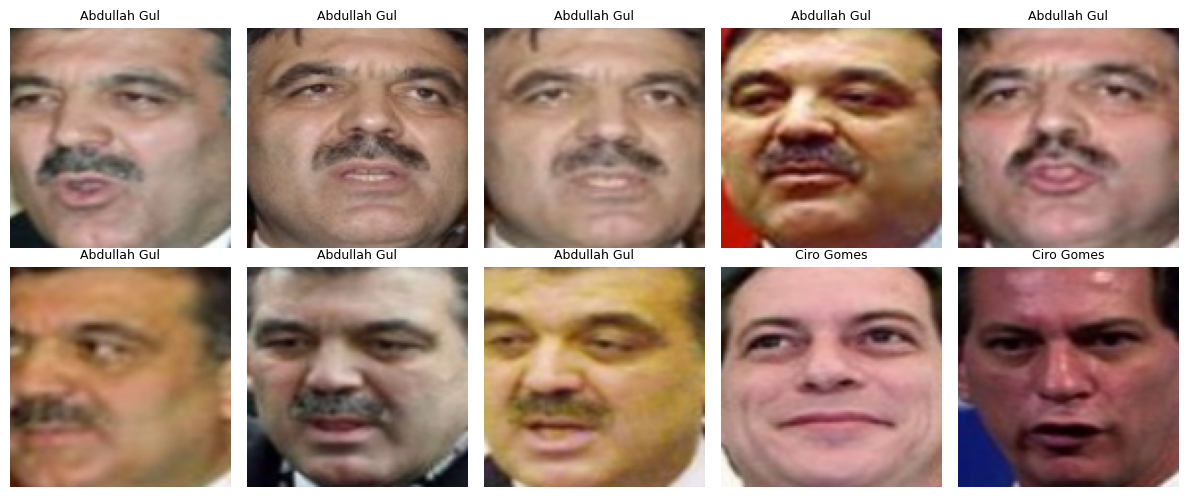

In [4]:
# ============================================================
# Cell 3. Load Color LFW
# ============================================================
class FaceDataset(Dataset):
    def __init__(self, items):
        self.items = list(items)
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        item = self.items[idx]
        landmarks = item.get('landmarks', CANONICAL_LANDMARKS_112)
        return {
            'image': pil_to_model_tensor(item['pil']),
            'identity': item['identity'],
            'index': idx,
            'role': item.get('role', 'unknown'),
            'local_index': item.get('local_index', -1),
            'lfw_index': item.get('lfw_index', -1),
            'landmarks': torch.tensor(landmarks, dtype=torch.float32),
            'landmark_source': item.get('landmark_source', 'unknown'),
        }

def load_lfw_items(num_identities=NUM_IDENTITIES, min_faces_per_person=MIN_FACES_PER_PERSON):
    lfw = fetch_lfw_people(
        min_faces_per_person=min_faces_per_person,
        resize=1.0,
        color=True,
        funneled=True,
    )
    by_id = defaultdict(list)
    for idx, img in enumerate(lfw.images):
        identity = str(lfw.target_names[lfw.target[idx]])
        by_id[identity].append({'identity': identity, 'pil': numpy_face_to_pil(img), 'lfw_index': idx})

    eligible = [(identity, imgs) for identity, imgs in by_id.items() if len(imgs) >= ENROLL_IMAGES_PER_ID + 1]
    eligible = sorted(eligible, key=lambda x: x[0])
    rng = np.random.default_rng(SEED)
    rng.shuffle(eligible)
    selected = eligible[:num_identities]

    enroll_items, probe_items = [], []
    for identity, imgs in selected:
        imgs = list(imgs)
        rng.shuffle(imgs)
        enroll_imgs = imgs[:ENROLL_IMAGES_PER_ID]
        probe_imgs = imgs[ENROLL_IMAGES_PER_ID:ENROLL_IMAGES_PER_ID + MAX_PROBES_PER_ID]
        for j, face_item in enumerate(enroll_imgs):
            enroll_items.append({'identity': identity, 'pil': face_item['pil'], 'lfw_index': face_item['lfw_index'], 'role': 'enroll', 'local_index': j})
        for j, face_item in enumerate(probe_imgs):
            probe_items.append({'identity': identity, 'pil': face_item['pil'], 'lfw_index': face_item['lfw_index'], 'role': 'probe', 'local_index': j})
    return enroll_items, probe_items

enroll_items, probe_items = load_lfw_items()
print('Enrollment images:', len(enroll_items))
print('Probe images:', len(probe_items))
print('Identities:', len(set([x['identity'] for x in enroll_items])))

split_rows = []
for i, item in enumerate(enroll_items):
    split_rows.append({'dataset': 'enroll', 'row': i, 'identity': item['identity'], 'local_index': item['local_index'], 'lfw_index': item['lfw_index']})
for i, item in enumerate(probe_items):
    split_rows.append({'dataset': 'probe', 'row': i, 'identity': item['identity'], 'local_index': item['local_index'], 'lfw_index': item['lfw_index']})
pd.DataFrame(split_rows).to_csv(PREREQ_DIR / 'lfw_color_split_metadata.csv', index=False)

show_pil_grid(
    [x['pil'].resize((112, 112)) for x in probe_items[:10]],
    [x['identity'][:12] for x in probe_items[:10]],
    ncols=5,
    figsize=(12, 5),
    save_path=PROCESS_DIR / '00_raw_color_lfw_samples.png',
)


Detect landmarks for enroll_items:   0%|          | 0/100 [00:00<?, ?it/s]

enroll_items: mtcnn=99, fallback=1


Detect landmarks for probe_items:   0%|          | 0/629 [00:00<?, ?it/s]

probe_items: mtcnn=627, fallback=2
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/process_visuals/01_raw_to_mtcnn_to_landmark_process.png


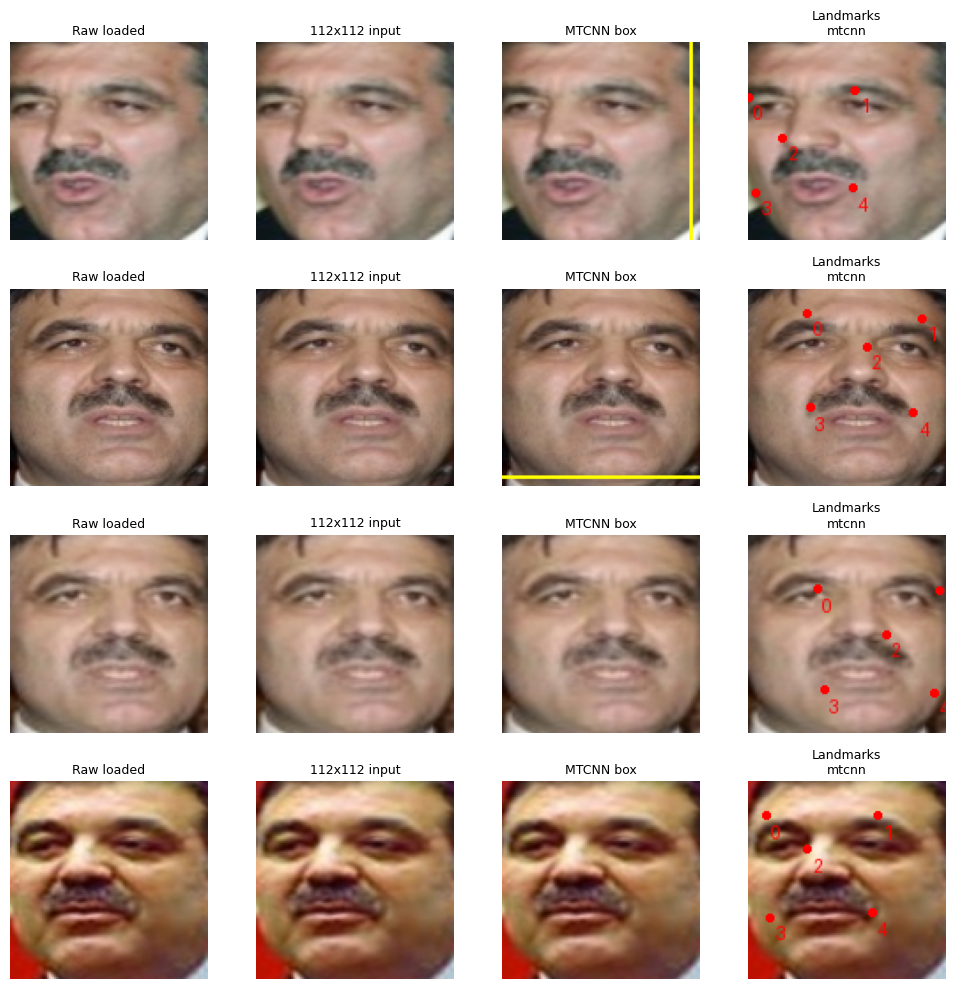

In [5]:
# ============================================================
# Cell 4. Landmark Detection
# ============================================================
try:
    from facenet_pytorch import MTCNN
except ImportError:
    !pip -q install facenet-pytorch --no-deps
    from facenet_pytorch import MTCNN

LANDMARK_MTCNN = MTCNN(image_size=112, margin=0, keep_all=True, post_process=False, device=DEVICE)

def detect_landmarks_112(pil, detector=LANDMARK_MTCNN):
    img112 = pil.convert('RGB').resize((112, 112), Image.BILINEAR)
    try:
        boxes, probs, landmarks = detector.detect(img112, landmarks=True)
    except Exception:
        boxes, probs, landmarks = None, None, None
    if landmarks is not None and len(landmarks) > 0:
        if probs is None:
            best_idx, best_prob = 0, np.nan
        else:
            probs_arr = np.asarray(probs, dtype=np.float32)
            best_idx = int(np.nan_to_num(probs_arr, nan=-1.0).argmax())
            best_prob = float(probs_arr[best_idx])
        lm = np.asarray(landmarks[best_idx], dtype=np.float32)
        if lm.shape == (5, 2) and np.isfinite(lm).all():
            lm[:, 0] = np.clip(lm[:, 0], 0, 111)
            lm[:, 1] = np.clip(lm[:, 1], 0, 111)
            box = None
            if boxes is not None and len(boxes) > best_idx:
                box = np.asarray(boxes[best_idx], dtype=np.float32)
            return lm, 'mtcnn', best_prob, box
    if LANDMARK_FALLBACK_TO_CANONICAL:
        return CANONICAL_LANDMARKS_112.copy(), 'canonical_fallback', np.nan, None
    raise RuntimeError('MTCNN landmark detection failed and fallback is disabled.')

def add_landmarks_to_items(items, desc='items'):
    mtcnn_count, fallback_count = 0, 0
    for item in tqdm(items, desc=f'Detect landmarks for {desc}'):
        landmarks, source, prob, box = detect_landmarks_112(item['pil'])
        item['landmarks'] = landmarks
        item['landmark_source'] = source
        item['landmark_prob'] = prob
        item['mtcnn_box'] = box
        if source == 'mtcnn':
            mtcnn_count += 1
        else:
            fallback_count += 1
    print(f'{desc}: mtcnn={mtcnn_count}, fallback={fallback_count}')

def draw_landmarks_on_pil(pil, landmarks, radius=2):
    img = pil.convert('RGB').resize((112, 112), Image.BILINEAR)
    draw = ImageDraw.Draw(img)
    for i, (x, y) in enumerate(np.asarray(landmarks)):
        draw.ellipse([x-radius, y-radius, x+radius, y+radius], fill=(255, 0, 0))
        draw.text((x+3, y+3), str(i), fill=(255, 0, 0))
    return img

def draw_mtcnn_box(pil, box):
    img = pil.convert('RGB').resize((112, 112), Image.BILINEAR)
    draw = ImageDraw.Draw(img)
    if box is not None:
        x1, y1, x2, y2 = [float(v) for v in box]
        draw.rectangle([x1, y1, x2, y2], outline=(255, 255, 0), width=2)
    return img

add_landmarks_to_items(enroll_items, desc='enroll_items')
add_landmarks_to_items(probe_items, desc='probe_items')

enroll_ds = FaceDataset(enroll_items)
probe_ds = FaceDataset(probe_items)

landmark_rows = []
for dataset_name, items in [('enroll', enroll_items), ('probe', probe_items)]:
    for i, item in enumerate(items):
        row = {'dataset': dataset_name, 'row': i, 'identity': item['identity'], 'lfw_index': item['lfw_index'], 'landmark_source': item.get('landmark_source'), 'landmark_prob': item.get('landmark_prob')}
        for j, name in enumerate(['left_eye', 'right_eye', 'nose', 'left_mouth', 'right_mouth']):
            row[f'{name}_x'] = float(item['landmarks'][j, 0])
            row[f'{name}_y'] = float(item['landmarks'][j, 1])
        landmark_rows.append(row)
pd.DataFrame(landmark_rows).to_csv(PREREQ_DIR / 'landmark_metadata.csv', index=False)

process_imgs, process_titles = [], []
for item in probe_items[:4]:
    raw = item['pil'].convert('RGB')
    process_imgs.extend([
        raw.resize((112, 112)),
        raw.resize((112, 112), Image.BILINEAR),
        draw_mtcnn_box(raw, item.get('mtcnn_box', None)),
        draw_landmarks_on_pil(raw, item['landmarks']),
    ])
    process_titles.extend(['Raw loaded', '112x112 input', 'MTCNN box', f"Landmarks\n{item['landmark_source']}"])
show_pil_grid(process_imgs, process_titles, ncols=4, figsize=(10, 10), save_path=PROCESS_DIR / '01_raw_to_mtcnn_to_landmark_process.png')


In [6]:
# ============================================================
# Cell 5. Model / Metrics
# ============================================================
MODEL_CACHE = {}

def load_cvlface_model(model_name: str, device: str = DEVICE):
    if model_name in MODEL_CACHE:
        return MODEL_CACHE[model_name]
    local_path = snapshot_download(
        repo_id=model_name,
        local_dir=f"/content/{model_name.replace('/', '_')}",
        local_dir_use_symlinks=False,
    )
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    cwd = os.getcwd()
    os.chdir(local_path)
    try:
        model = AutoModel.from_pretrained(local_path, trust_remote_code=True, torch_dtype=torch.float32, local_files_only=True)
    finally:
        os.chdir(cwd)
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    MODEL_CACHE[model_name] = (model, local_path)
    print('Loaded:', model_name)
    print('Local path:', local_path)
    return model, local_path

def forward_embedding(model, x):
    out = model(x)
    if isinstance(out, dict):
        for key in ['embeddings', 'embedding', 'last_hidden_state', 'pooler_output']:
            if key in out:
                out = out[key]
                break
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.ndim > 2:
        out = torch.flatten(out, start_dim=1)
    return F.normalize(out.float(), p=2, dim=1)

@torch.no_grad()
def extract_embeddings(model, dataset, batch_size=BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    embs, ids, indices = [], [], []
    for batch in tqdm(loader, desc='Extract embeddings'):
        x = batch['image'].to(DEVICE)
        emb = forward_embedding(model, x).cpu()
        embs.append(emb)
        ids.extend(list(batch['identity']))
        idxs = batch['index']
        if torch.is_tensor(idxs):
            idxs = idxs.cpu().numpy().tolist()
        indices.extend(idxs)
    return torch.cat(embs, dim=0), ids, indices

def build_enrollment_db(enroll_embs, enroll_ids):
    by_id = defaultdict(list)
    for emb, identity in zip(enroll_embs, enroll_ids):
        by_id[identity].append(emb)
    db_ids = sorted(by_id.keys())
    db_embs = []
    for identity in db_ids:
        emb = torch.stack(by_id[identity], dim=0).mean(dim=0)
        db_embs.append(F.normalize(emb, p=2, dim=0))
    return torch.stack(db_embs, dim=0), db_ids

def compute_threshold_from_impostors(sim_mat, probe_ids, db_ids, target_far=TARGET_FAR):
    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}
    impostor_sims = []
    for i, identity in enumerate(probe_ids):
        true_idx = id_to_db_idx[identity]
        mask = np.ones(len(db_ids), dtype=bool)
        mask[true_idx] = False
        impostor_sims.extend(sim_mat[i, mask].tolist())
    impostor_sims = np.array(impostor_sims, dtype=np.float32)
    threshold = float(np.quantile(impostor_sims, 1.0 - target_far))
    actual_far = float((impostor_sims >= threshold).mean())
    return threshold, actual_far, impostor_sims

def compute_facepay_metrics(embs, ids, db_embs, db_ids, threshold):
    sim_mat = (embs @ db_embs.T).cpu().numpy()
    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}
    true_indices = np.array([id_to_db_idx[i] for i in ids])
    top1_indices = sim_mat.argmax(axis=1)
    top1_sims = sim_mat[np.arange(len(ids)), top1_indices]
    true_sims = sim_mat[np.arange(len(ids)), true_indices]
    top1_correct = top1_indices == true_indices
    accepted = top1_sims >= threshold
    correct_accept = top1_correct & accepted
    false_reject = ~accepted
    misidentified = ~top1_correct
    misaccept = misidentified & accepted
    metrics = {
        'n': int(len(ids)),
        'rank1_acc': float(top1_correct.mean()),
        'correct_accept_rate': float(correct_accept.mean()),
        'false_reject_rate': float(false_reject.mean()),
        'misid_rate': float(misidentified.mean()),
        'misaccept_rate': float(misaccept.mean()),
        'avg_top1_sim': float(top1_sims.mean()),
        'avg_true_sim': float(true_sims.mean()),
        'threshold': float(threshold),
    }
    detail = pd.DataFrame({
        'probe_row': np.arange(len(ids)),
        'identity': ids,
        'true_db_idx': true_indices,
        'top1_db_idx': top1_indices,
        'top1_identity': [db_ids[i] for i in top1_indices],
        'top1_similarity': top1_sims,
        'true_similarity': true_sims,
        'rank1_correct': top1_correct,
        'accepted': accepted,
        'correct_accept': correct_accept,
        'false_reject': false_reject,
        'misidentified': misidentified,
        'misaccept': misaccept,
    })
    return metrics, detail, sim_mat


In [7]:
# ============================================================
# Cell 6. Clean Baseline Prerequisite
# ============================================================
# Exp03용 threshold, db_embs, clean_eval_indices를 계산한다.
# 기존 Exp01/Exp02 결과 폴더에는 저장하지 않는다.

model, model_path = load_cvlface_model(MODEL_NAME)

enroll_embs_raw, enroll_ids_raw, enroll_indices = extract_embeddings(model, enroll_ds)
db_embs, db_ids = build_enrollment_db(enroll_embs_raw, enroll_ids_raw)
probe_embs, probe_ids, probe_indices = extract_embeddings(model, probe_ds)

clean_sim_mat = (probe_embs @ db_embs.T).cpu().numpy()
threshold, actual_far, impostor_sims = compute_threshold_from_impostors(clean_sim_mat, probe_ids, db_ids, target_far=TARGET_FAR)
clean_metrics, clean_detail_df, _ = compute_facepay_metrics(probe_embs, probe_ids, db_embs, db_ids, threshold)

clean_eval_mask = clean_detail_df['rank1_correct'].values & clean_detail_df['accepted'].values
clean_eval_indices = clean_detail_df.loc[clean_eval_mask, 'probe_row'].astype(int).tolist()

clean_metrics.update({
    'model_name': MODEL_NAME,
    'model_short_name': MODEL_SHORT_NAME,
    'target_far': TARGET_FAR,
    'actual_far': actual_far,
    'n_identities': len(db_ids),
    'n_enroll': len(enroll_ds),
    'n_probe': len(probe_ds),
    'clean_eval_n': len(clean_eval_indices),
    'lfw_color': True,
    'lfw_funneled': True,
    'run_tag': RUN_TAG,
})
clean_detail_df['model_name'] = MODEL_NAME
clean_detail_df['model_short_name'] = MODEL_SHORT_NAME

pd.DataFrame([clean_metrics]).to_csv(PREREQ_DIR / 'clean_baseline_prereq_summary.csv', index=False)
clean_detail_df.to_csv(PREREQ_DIR / 'clean_baseline_prereq_detail.csv', index=False)
torch.save(db_embs, PREREQ_DIR / 'db_embs.pt')
with open(PREREQ_DIR / 'db_ids.json', 'w', encoding='utf-8') as f:
    json.dump(db_ids, f, ensure_ascii=False, indent=2)
with open(PREREQ_DIR / 'threshold.json', 'w', encoding='utf-8') as f:
    json.dump({'target_far': TARGET_FAR, 'actual_far': actual_far, 'threshold': threshold}, f, ensure_ascii=False, indent=2)

print('Threshold:', threshold)
print('Actual FAR:', actual_far)
print('Clean eval probes:', len(clean_eval_indices))
display(pd.DataFrame([clean_metrics]))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

example.yaml:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

files.txt:   0%|          | 0.00/350 [00:00<?, ?B/s]

...

Loaded iResNet model
compatible keys in state_dict 917 / 917
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt
Loaded: minchul/cvlface_adaface_ir101_webface12m
Local path: /content/minchul_cvlface_adaface_ir101_webface12m


Extract embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Extract embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Threshold: 0.16163350641727448
Actual FAR: 0.010004657063480592
Clean eval probes: 614


,n,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,threshold,model_name,model_short_name,target_far,actual_far,n_identities,n_enroll,n_probe,clean_eval_n,lfw_color,lfw_funneled,run_tag
0,629,0.976153,0.976153,0.00318,0.023847,0.020668,0.491778,0.490452,0.161634,minchul/cvlface_adaface_ir101_webface12m,adaface_ir101_wf12m,0.01,0.010005,100,100,629,614,True,True,run_20260615_122035


In [8]:
# ============================================================
# Cell 7. Sticker Placement Utilities
# ============================================================
LOCATION_CENTERS = {
    'forehead': (56, 30),
    'nose_bridge': (56, 45),
    'center': (56, 56),
    'nose': (56, 60),
    'left_cheek': (42, 66),
    'right_cheek': (70, 66),
    'left_under_eye': (43, 52),
    'right_under_eye': (69, 52),
    'under_eye': (56, 52),
    'mouth': (56, 76),
    'chin': (56, 88),
}

def get_patch_size_px(patch_size_ratio, image_size=112):
    return max(4, min(image_size, int(round(image_size * float(patch_size_ratio)))))

def get_landmark_based_centers(landmarks, location, image_size=112):
    if location not in LOCATION_CENTERS:
        raise ValueError(f'Unknown location: {location}')
    lm = landmarks
    if not torch.is_tensor(lm):
        lm = torch.tensor(lm, dtype=torch.float32)
    lm = lm.float()
    if lm.ndim == 2:
        lm = lm.unsqueeze(0)
    if lm.ndim != 3 or lm.shape[1:] != (5, 2):
        raise ValueError(f'landmarks must be [B,5,2] or [5,2], got {tuple(lm.shape)}')

    left_eye = lm[:, 0, :]
    right_eye = lm[:, 1, :]
    nose = lm[:, 2, :]
    left_mouth = lm[:, 3, :]
    right_mouth = lm[:, 4, :]
    eye_mid = (left_eye + right_eye) / 2.0
    mouth_mid = (left_mouth + right_mouth) / 2.0
    eye_dist = torch.linalg.norm(right_eye - left_eye, dim=1, keepdim=True).clamp(min=8.0)

    if location == 'nose_bridge':
        center = 0.55 * eye_mid + 0.45 * nose
    elif location in ['center', 'nose']:
        center = nose
    elif location == 'forehead':
        center = eye_mid + 0.75 * (eye_mid - nose)
    elif location == 'left_under_eye':
        center = 0.65 * left_eye + 0.35 * nose
    elif location == 'right_under_eye':
        center = 0.65 * right_eye + 0.35 * nose
    elif location == 'under_eye':
        center = ((0.65 * left_eye + 0.35 * nose) + (0.65 * right_eye + 0.35 * nose)) / 2.0
    elif location == 'left_cheek':
        center = 0.35 * left_eye + 0.65 * left_mouth
        center = center + torch.cat([-0.22 * eye_dist, -0.03 * eye_dist], dim=1)
    elif location == 'right_cheek':
        center = 0.35 * right_eye + 0.65 * right_mouth
        center = center + torch.cat([0.22 * eye_dist, -0.03 * eye_dist], dim=1)
    elif location == 'mouth':
        center = mouth_mid
    elif location == 'chin':
        center = mouth_mid + 0.80 * (mouth_mid - nose)
    else:
        fixed = torch.tensor(LOCATION_CENTERS[location], dtype=lm.dtype, device=lm.device)
        center = fixed[None, :].expand(lm.shape[0], -1)

    center[:, 0] = center[:, 0].clamp(0, image_size - 1)
    center[:, 1] = center[:, 1].clamp(0, image_size - 1)
    return center

def centers_to_top_lefts(centers, patch_size_px, image_size=112):
    x0 = torch.round(centers[:, 0] - patch_size_px / 2.0).long()
    y0 = torch.round(centers[:, 1] - patch_size_px / 2.0).long()
    x0 = x0.clamp(0, image_size - patch_size_px)
    y0 = y0.clamp(0, image_size - patch_size_px)
    return torch.stack([x0, y0], dim=1)

def get_patch_top_lefts(location, patch_size_px, batch_size, image_size=112, landmarks=None, device=DEVICE):
    if USE_LANDMARK_BASED_PLACEMENT and landmarks is not None:
        centers = get_landmark_based_centers(landmarks, location, image_size=image_size).to(device)
        return centers_to_top_lefts(centers, patch_size_px, image_size=image_size)
    cx, cy = LOCATION_CENTERS[location]
    x0 = max(0, min(image_size - patch_size_px, int(round(cx - patch_size_px / 2))))
    y0 = max(0, min(image_size - patch_size_px, int(round(cy - patch_size_px / 2))))
    return torch.tensor([[x0, y0]], dtype=torch.long, device=device).expand(batch_size, -1)

def load_mascot_patch_and_mask(patch_size_px, mascot_path=MASCOT_PATH, device=DEVICE):
    img = Image.open(mascot_path).convert('RGBA').resize((patch_size_px, patch_size_px), Image.BILINEAR)
    arr = np.asarray(img).astype(np.float32) / 255.0
    rgb = arr[:, :, :3]
    alpha = arr[:, :, 3:4]
    patch = torch.tensor(rgb).permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0
    mask = torch.tensor(alpha).permute(2, 0, 1).unsqueeze(0)[:, :1].clamp(0, 1)
    return patch.to(device).float(), mask.to(device).float()

def apply_patch_tensor(x, patch, mask, location, landmarks=None):
    B, C, H, W = x.shape
    image_size = min(H, W)
    P = patch.shape[-1]
    top_lefts = get_patch_top_lefts(location, P, B, image_size=image_size, landmarks=landmarks, device=x.device)
    x_adv = x.clone()
    patch_b = patch.to(x.device, dtype=x.dtype)
    mask_b = mask.to(x.device, dtype=x.dtype)
    for i in range(B):
        x0 = int(top_lefts[i, 0].item())
        y0 = int(top_lefts[i, 1].item())
        region = x_adv[i:i+1, :, y0:y0+P, x0:x0+P]
        x_adv[i:i+1, :, y0:y0+P, x0:x0+P] = region * (1.0 - mask_b) + patch_b * mask_b
    return x_adv

def add_patch_to_pil_for_visual(pil, patch, mask, location, landmarks=None):
    x = pil_to_model_tensor(pil).unsqueeze(0).to(DEVICE)
    lm = None
    if landmarks is not None:
        lm = torch.tensor(landmarks, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    y = apply_patch_tensor(x, patch=patch.to(DEVICE), mask=mask.to(DEVICE), location=location, landmarks=lm)
    return tensor_to_pil(y[0])


In [9]:
# ============================================================
# Cell 8. Evaluation and Optimization Utilities
# ============================================================
class IndexedSubsetDataset(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds
        self.indices = list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        item = dict(self.base_ds[base_idx])
        item['base_probe_row'] = base_idx
        return item

eval_ds = IndexedSubsetDataset(probe_ds, clean_eval_indices)
print('Eval subset size:', len(eval_ds))

@torch.no_grad()
def extract_embeddings_with_patch(model, dataset, patch=None, mask=None, location='nose_bridge', batch_size=BATCH_SIZE, desc='Eval'):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    embs, ids, base_probe_rows = [], [], []
    for batch in tqdm(loader, desc=desc):
        x = batch['image'].to(DEVICE)
        landmarks = batch.get('landmarks', None)
        if landmarks is not None:
            landmarks = landmarks.to(DEVICE)
        if patch is not None and mask is not None:
            x = apply_patch_tensor(x, patch=patch, mask=mask, location=location, landmarks=landmarks)
        emb = forward_embedding(model, x).cpu()
        embs.append(emb)
        ids.extend(list(batch['identity']))
        rows = batch.get('base_probe_row', batch.get('index', None))
        if rows is None:
            rows = torch.arange(len(ids)-len(batch['identity']), len(ids))
        if torch.is_tensor(rows):
            rows = rows.cpu().numpy().tolist()
        base_probe_rows.extend(rows)
    return torch.cat(embs, dim=0), ids, base_probe_rows

def evaluate_condition(condition_name, dataset, patch=None, mask=None, location='nose_bridge', patch_size_ratio=None, patch_size_px=None, save_detail_path=None):
    embs, ids, base_probe_rows = extract_embeddings_with_patch(model, dataset, patch=patch, mask=mask, location=location, desc=f'Eval {condition_name} {location}')
    metrics, detail, _ = compute_facepay_metrics(embs, ids, db_embs, db_ids, threshold)
    clean_true_map = clean_detail_df.set_index('probe_row')['true_similarity'].to_dict()
    before_true = np.array([clean_true_map[i] for i in base_probe_rows])
    after_true = detail['true_similarity'].values
    metrics.update({
        'model_short_name': MODEL_SHORT_NAME,
        'model_name': MODEL_NAME,
        'condition': condition_name,
        'placement': 'landmark_relative' if USE_LANDMARK_BASED_PLACEMENT else 'fixed_coordinate',
        'location': location,
        'patch_size_ratio': float(patch_size_ratio) if patch_size_ratio is not None else np.nan,
        'patch_size_px': int(patch_size_px) if patch_size_px is not None else -1,
        'threshold': float(threshold),
        'avg_similarity_drop': float((before_true - after_true).mean()),
        'run_tag': RUN_TAG,
    })
    detail['model_short_name'] = MODEL_SHORT_NAME
    detail['condition'] = condition_name
    detail['placement'] = metrics['placement']
    detail['location'] = location
    detail['patch_size_ratio'] = metrics['patch_size_ratio']
    detail['patch_size_px'] = metrics['patch_size_px']
    detail['base_probe_row'] = base_probe_rows
    detail['similarity_drop_from_clean'] = before_true - after_true
    if save_detail_path is not None:
        save_detail_path = Path(save_detail_path)
        save_detail_path.parent.mkdir(parents=True, exist_ok=True)
        detail.to_csv(save_detail_path, index=False)
        print('Saved detail:', save_detail_path)
    return metrics, detail

def total_variation_loss(patch, mask=None):
    if mask is not None:
        patch = patch * mask
    dx = torch.mean(torch.abs(patch[:, :, :, 1:] - patch[:, :, :, :-1]))
    dy = torch.mean(torch.abs(patch[:, :, 1:, :] - patch[:, :, :-1, :]))
    return dx + dy

def optimize_adversarial_sticker(model, dataset, db_embs, db_ids, init_patch, shape_mask, location, patch_size_ratio, patch_size_px, steps=ATTACK_STEPS, batch_size=ATTACK_BATCH_SIZE, lr=ATTACK_LR):
    db_t = db_embs.to(DEVICE)
    threshold_t = torch.tensor(float(threshold), device=DEVICE)
    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}
    patch = init_patch.clone().detach().to(DEVICE)
    mask = shape_mask.clone().detach().to(DEVICE)
    patch.requires_grad_(True)
    optimizer = torch.optim.Adam([patch], lr=lr)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    history, step_iter = [], 0
    pbar = tqdm(total=steps, desc=f'Optimize {location}, size={patch_size_ratio:.2f}')
    while step_iter < steps:
        for batch in loader:
            if step_iter >= steps:
                break
            x = batch['image'].to(DEVICE)
            ids = list(batch['identity'])
            landmarks = batch.get('landmarks', None)
            if landmarks is not None:
                landmarks = landmarks.to(DEVICE)
            true_idx = torch.tensor([id_to_db_idx[i] for i in ids], dtype=torch.long, device=DEVICE)
            patched_x = apply_patch_tensor(x, patch=patch.clamp(-1, 1), mask=mask, location=location, landmarks=landmarks)
            emb = forward_embedding(model, patched_x)
            sim = emb @ db_t.T
            batch_arange = torch.arange(sim.shape[0], device=DEVICE)
            true_sim = sim[batch_arange, true_idx]
            sim_other = sim.clone()
            sim_other[batch_arange, true_idx] = -1e9
            max_impostor_sim, _ = sim_other.max(dim=1)
            soft_impostor_sim = TAU * torch.logsumexp(sim_other / TAU, dim=1)
            loss_true = true_sim.mean()
            loss_imp = -soft_impostor_sim.mean()
            loss_thresh = torch.relu(threshold_t + THRESHOLD_MARGIN - soft_impostor_sim).mean()
            loss_rank = torch.relu(true_sim - soft_impostor_sim + MARGIN).mean()
            tv = total_variation_loss(patch, mask)
            attack_loss = LAMBDA_TRUE*loss_true + LAMBDA_IMP*loss_imp + LAMBDA_THRESH*loss_thresh + LAMBDA_RANK*loss_rank
            loss = attack_loss + TV_WEIGHT * tv
            optimizer.zero_grad()
            loss.backward()
            grad_norm = patch.grad.detach().abs().mean().item() if patch.grad is not None else 0.0
            optimizer.step()
            with torch.no_grad():
                patch.clamp_(-1, 1)
            if step_iter % 10 == 0 or step_iter == steps - 1:
                with torch.no_grad():
                    row = {
                        'step': step_iter,
                        'location': location,
                        'patch_size_ratio': float(patch_size_ratio),
                        'patch_size_px': int(patch_size_px),
                        'loss': float(loss.detach().cpu()),
                        'attack_loss': float(attack_loss.detach().cpu()),
                        'loss_true': float(loss_true.detach().cpu()),
                        'loss_imp': float(loss_imp.detach().cpu()),
                        'loss_thresh': float(loss_thresh.detach().cpu()),
                        'loss_rank': float(loss_rank.detach().cpu()),
                        'tv': float(tv.detach().cpu()),
                        'true_sim': float(true_sim.mean().detach().cpu()),
                        'soft_impostor_sim': float(soft_impostor_sim.mean().detach().cpu()),
                        'max_impostor_sim': float(max_impostor_sim.mean().detach().cpu()),
                        'gap_true_minus_impostor': float((true_sim - max_impostor_sim).mean().detach().cpu()),
                        'frac_imp_over_threshold': float((max_impostor_sim > threshold_t).float().mean().detach().cpu()),
                        'frac_misrank': float((max_impostor_sim > true_sim).float().mean().detach().cpu()),
                        'grad_norm': float(grad_norm),
                    }
                    history.append(row)
                    pbar.set_postfix({'loss': row['loss'], 'true': row['true_sim'], 'imp': row['max_impostor_sim'], 'misrank': row['frac_misrank']})
            step_iter += 1
            pbar.update(1)
    pbar.close()
    return patch.detach().clamp(-1, 1), mask, pd.DataFrame(history)


Eval subset size: 614


In [10]:
# ============================================================
# Cell 9. Run Exp03 Location Ablation
# ============================================================
print('\n' + '=' * 80)
print('Exp03. Location ablation only')
print('=' * 80)

EXP03_PATCH_SIZE_PX = get_patch_size_px(EXP03_PATCH_SIZE_RATIO)
print('Locations:', EXP03_LOCATIONS)
print('Patch size ratio:', EXP03_PATCH_SIZE_RATIO)
print('Patch size px:', EXP03_PATCH_SIZE_PX)

normal_patch_exp03, normal_mask_exp03 = load_mascot_patch_and_mask(EXP03_PATCH_SIZE_PX, mascot_path=MASCOT_PATH, device=DEVICE)
save_patch_png(normal_patch_exp03, normal_mask_exp03, EXP03_PATCH_DIR / '03_normal_mascot_sticker.png')

exp03_rows = []
exp03_details = {}
exp03_adv_patches = {}
exp03_adv_masks = {}
exp03_histories = {}

for loc in EXP03_LOCATIONS:
    print('\n' + '=' * 80)
    print(f'Exp03 location: {loc}')
    print('=' * 80)

    normal_metrics_loc, normal_detail_loc = evaluate_condition(
        condition_name='normal_mascot_sticker',
        dataset=eval_ds,
        patch=normal_patch_exp03,
        mask=normal_mask_exp03,
        location=loc,
        patch_size_ratio=EXP03_PATCH_SIZE_RATIO,
        patch_size_px=EXP03_PATCH_SIZE_PX,
        save_detail_path=EXP03_DETAIL_DIR / f'03_{loc}_normal_mascot_sticker_detail.csv',
    )
    exp03_rows.append(normal_metrics_loc)
    exp03_details[(loc, 'normal')] = normal_detail_loc

    adv_patch_loc, adv_mask_loc, history_loc = optimize_adversarial_sticker(
        model=model,
        dataset=eval_ds,
        db_embs=db_embs,
        db_ids=db_ids,
        init_patch=normal_patch_exp03,
        shape_mask=normal_mask_exp03,
        location=loc,
        patch_size_ratio=EXP03_PATCH_SIZE_RATIO,
        patch_size_px=EXP03_PATCH_SIZE_PX,
        steps=ATTACK_STEPS,
        batch_size=ATTACK_BATCH_SIZE,
        lr=ATTACK_LR,
    )
    exp03_adv_patches[loc] = adv_patch_loc
    exp03_adv_masks[loc] = adv_mask_loc
    exp03_histories[loc] = history_loc

    save_patch_png(adv_patch_loc, adv_mask_loc, EXP03_PATCH_DIR / f'03_adv_mascot_{loc}.png')
    torch.save({
        'patch': adv_patch_loc.detach().cpu(),
        'mask': adv_mask_loc.detach().cpu(),
        'model_name': MODEL_NAME,
        'model_short_name': MODEL_SHORT_NAME,
        'placement': 'landmark_relative',
        'location': loc,
        'patch_size_ratio': EXP03_PATCH_SIZE_RATIO,
        'patch_size_px': EXP03_PATCH_SIZE_PX,
        'threshold': float(threshold),
        'attack_steps': ATTACK_STEPS,
        'attack_lr': ATTACK_LR,
        'run_tag': RUN_TAG,
    }, EXP03_PATCH_DIR / f'03_adv_mascot_{loc}.pt')
    history_loc.to_csv(EXP03_HISTORY_DIR / f'03_attack_history_{loc}.csv', index=False)

    adv_metrics_loc, adv_detail_loc = evaluate_condition(
        condition_name='adversarial_mascot_sticker',
        dataset=eval_ds,
        patch=adv_patch_loc,
        mask=adv_mask_loc,
        location=loc,
        patch_size_ratio=EXP03_PATCH_SIZE_RATIO,
        patch_size_px=EXP03_PATCH_SIZE_PX,
        save_detail_path=EXP03_DETAIL_DIR / f'03_{loc}_adversarial_mascot_sticker_detail.csv',
    )
    exp03_rows.append(adv_metrics_loc)
    exp03_details[(loc, 'adversarial')] = adv_detail_loc

    intermediate_df = pd.DataFrame(exp03_rows)
    intermediate_df.to_csv(EXP03_DIR / '03_location_ablation_summary_intermediate.csv', index=False)
    display(intermediate_df[['condition', 'location', 'patch_size_ratio', 'patch_size_px', 'misaccept_rate', 'avg_similarity_drop']].tail(2))

exp03_summary_df = pd.DataFrame(exp03_rows)
summary_cols = [
    'model_short_name', 'condition', 'placement', 'n', 'location',
    'patch_size_ratio', 'patch_size_px', 'threshold', 'rank1_acc',
    'correct_accept_rate', 'false_reject_rate', 'misid_rate',
    'misaccept_rate', 'avg_top1_sim', 'avg_true_sim',
    'avg_similarity_drop', 'run_tag'
]
exp03_summary_df = exp03_summary_df[summary_cols]
exp03_summary_path = EXP03_DIR / '03_location_ablation_summary.csv'
exp03_summary_df.to_csv(exp03_summary_path, index=False)
print('Saved:', exp03_summary_path)
display(exp03_summary_df)



Exp03. Location ablation only
Locations: ['forehead', 'nose_bridge', 'right_cheek', 'chin', 'right_under_eye']
Patch size ratio: 0.3
Patch size px: 34
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/patches/03_normal_mascot_sticker.png

Exp03 location: forehead


Eval normal_mascot_sticker forehead:   0%|          | 0/10 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/details/03_forehead_normal_mascot_sticker_detail.csv


Optimize forehead, size=0.30:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/patches/03_adv_mascot_forehead.png


...

Eval adversarial_mascot_sticker right_under_eye:   0%|          | 0/10 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/details/03_right_under_eye_adversarial_mascot_sticker_detail.csv


,condition,location,patch_size_ratio,patch_size_px,misaccept_rate,avg_similarity_drop
8,normal_mascot_sticker,right_under_eye,0.3,34,0.000000,0.017244
9,adversarial_mascot_sticker,right_under_eye,0.3,34,0.032573,0.093414


Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/03_location_ablation_summary.csv


,model_short_name,condition,placement,n,location,patch_size_ratio,patch_size_px,threshold,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,avg_similarity_drop,run_tag
0,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,forehead,0.3,34,0.161634,0.996743,0.996743,0.000000,0.003257,0.003257,0.482734,0.482666,0.015962,run_20260615_122035
1,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,forehead,0.3,34,0.161634,0.967427,0.964169,0.006515,0.032573,0.029316,0.403951,0.402220,0.096408,run_20260615_122035
2,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,nose_bridge,0.3,34,0.161634,0.995114,0.995114,0.000000,0.004886,0.004886,0.466623,0.466520,0.032108,run_20260615_122035
3,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,nose_bridge,0.3,34,0.161634,0.607492,0.596091,0.117264,0.392508,0.286645,0.284460,0.251265,0.247363,run_20260615_122035
4,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,right_cheek,0.3,34,0.161634,1.000000,1.000000,0.000000,0.000000,0.000000,0.487909,0.487909,0.010719,run_20260615_122035
5,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,right_cheek,0.3,34,0.161634,0.956026,0.952769,0.014658,0.043974,0.032573,0.411727,0.409295,0.089333,run_20260615_122035
6,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,chin,0.3,34,0.161634,1.000000,0.998371,0.001629,0.000000,0.000000,0.481700,0.481700,0.016928,run_20260615_122035
7,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,chin,0.3,34,0.161634,0.916938,0.910423,0.029316,0.083062,0.060261,0.367221,0.363069,0.135559,run_20260615_122035
8,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,right_under_eye,0.3,34,0.161634,1.000000,1.000000,0.000000,0.000000,0.000000,0.481384,0.481384,0.017244,run_20260615_122035
9,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,right_under_eye,0.3,34,0.161634,0.964169,0.959283,0.008143,0.035831,0.032573,0.407481,0.405214,0.093414,run_20260615_122035


Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/figures/03_location_ablation_misaccept_rate.png


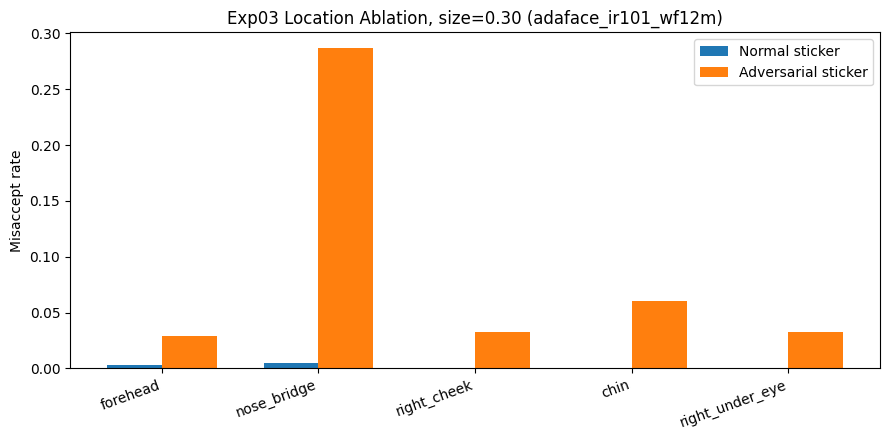

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/figures/03_location_ablation_similarity_drop.png


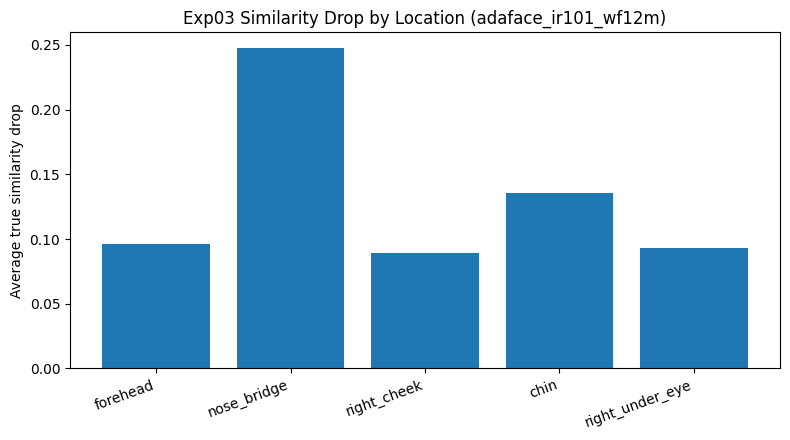

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/figures/03_location_ablation_rank1_acc.png


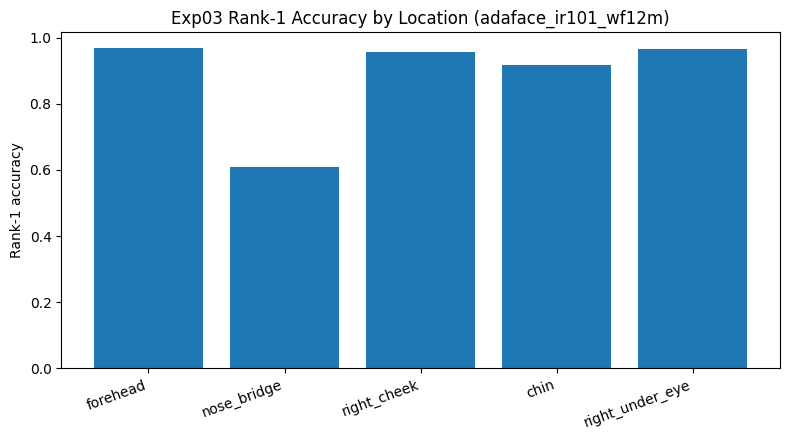

Best location: nose_bridge
Best misaccept: 0.28664495114006516
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/03_best_location.json


In [11]:
# ============================================================
# Cell 10. Exp03 Figures and Best Location
# ============================================================
plot_df = exp03_summary_df.copy()
available_locations = list(plot_df['location'].unique())
missing_locations = [loc for loc in EXP03_LOCATIONS if loc not in available_locations]
if missing_locations:
    raise ValueError(f'Exp03 결과에 없는 location: {missing_locations}')

pivot_misaccept = plot_df.pivot(index='location', columns='condition', values='misaccept_rate').reindex(EXP03_LOCATIONS)

plt.figure(figsize=(9, 4.5))
x = np.arange(len(pivot_misaccept.index))
width = 0.35
plt.bar(x - width/2, pivot_misaccept['normal_mascot_sticker'].values, width, label='Normal sticker')
plt.bar(x + width/2, pivot_misaccept['adversarial_mascot_sticker'].values, width, label='Adversarial sticker')
plt.xticks(x, pivot_misaccept.index, rotation=20, ha='right')
plt.ylabel('Misaccept rate')
plt.title(f'Exp03 Location Ablation, size={EXP03_PATCH_SIZE_RATIO:.2f} ({MODEL_SHORT_NAME})')
plt.legend()
plt.tight_layout()
fig_path = EXP03_FIG_DIR / '03_location_ablation_misaccept_rate.png'
plt.savefig(fig_path, dpi=220, bbox_inches='tight')
print('Saved:', fig_path)
plt.show()

adv_only_exp03 = exp03_summary_df[exp03_summary_df['condition'] == 'adversarial_mascot_sticker'].copy()
adv_only_exp03['location'] = pd.Categorical(adv_only_exp03['location'], categories=EXP03_LOCATIONS, ordered=True)
adv_only_exp03 = adv_only_exp03.sort_values('location')

plt.figure(figsize=(8, 4.5))
plt.bar(adv_only_exp03['location'], adv_only_exp03['avg_similarity_drop'])
plt.ylabel('Average true similarity drop')
plt.title(f'Exp03 Similarity Drop by Location ({MODEL_SHORT_NAME})')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
fig_path = EXP03_FIG_DIR / '03_location_ablation_similarity_drop.png'
plt.savefig(fig_path, dpi=220, bbox_inches='tight')
print('Saved:', fig_path)
plt.show()

plt.figure(figsize=(8, 4.5))
plt.bar(adv_only_exp03['location'], adv_only_exp03['rank1_acc'])
plt.ylabel('Rank-1 accuracy')
plt.title(f'Exp03 Rank-1 Accuracy by Location ({MODEL_SHORT_NAME})')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
fig_path = EXP03_FIG_DIR / '03_location_ablation_rank1_acc.png'
plt.savefig(fig_path, dpi=220, bbox_inches='tight')
print('Saved:', fig_path)
plt.show()

best_location_row = adv_only_exp03.sort_values('misaccept_rate', ascending=False).iloc[0]
EXP03_BEST_LOCATION = str(best_location_row['location'])
EXP03_BEST_MISACCEPT = float(best_location_row['misaccept_rate'])

best_info = {
    'best_location': EXP03_BEST_LOCATION,
    'best_misaccept_rate': EXP03_BEST_MISACCEPT,
    'patch_size_ratio': EXP03_PATCH_SIZE_RATIO,
    'patch_size_px': EXP03_PATCH_SIZE_PX,
    'model_short_name': MODEL_SHORT_NAME,
    'run_tag': RUN_TAG,
}
with open(EXP03_DIR / '03_best_location.json', 'w', encoding='utf-8') as f:
    json.dump(best_info, f, ensure_ascii=False, indent=2)

print('Best location:', EXP03_BEST_LOCATION)
print('Best misaccept:', EXP03_BEST_MISACCEPT)
print('Saved:', EXP03_DIR / '03_best_location.json')


Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/figures/03_location_ablation_same_face_grid.png


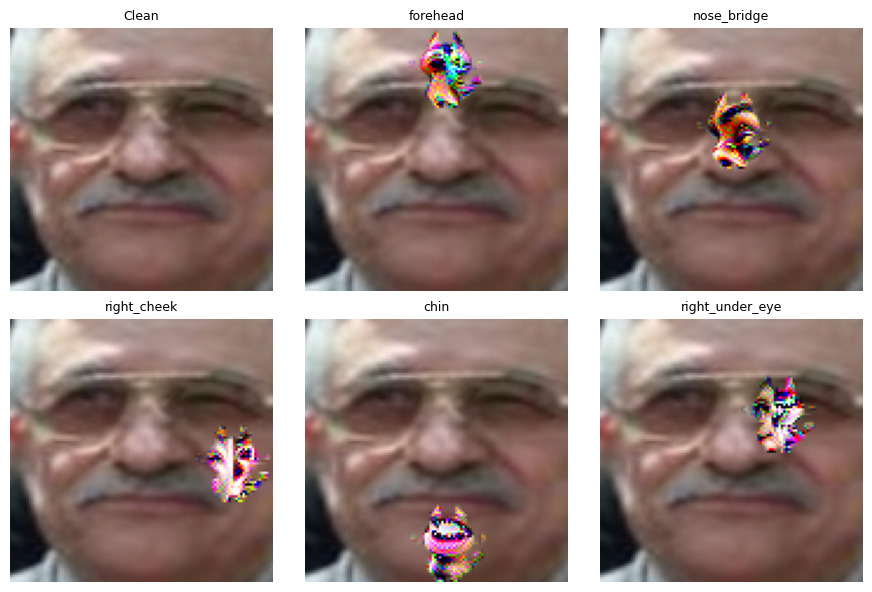

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/figures/03_best_location_random_misaccept_examples.png
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/03_best_location_random_misaccept_examples_metadata.csv


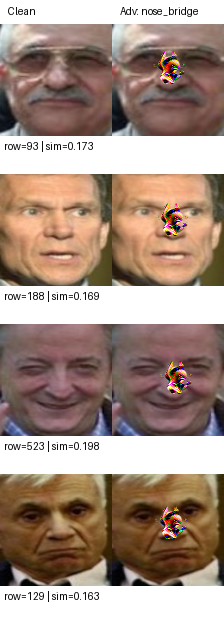

In [12]:
# ============================================================
# Cell 11. Exp03 Qualitative Visuals
# ============================================================
# A. 같은 얼굴에 위치별 adversarial sticker를 붙인 grid
best_detail = exp03_details.get((EXP03_BEST_LOCATION, 'adversarial'), None)

if best_detail is not None and len(best_detail[best_detail['misaccept'] == True]) > 0:
    sample_base_idx = int(best_detail[best_detail['misaccept'] == True].sample(n=1, random_state=SEED).iloc[0]['base_probe_row'])
else:
    sample_base_idx = int(clean_eval_indices[0])

sample_item = probe_items[sample_base_idx]
sample_pil = sample_item['pil']
sample_landmarks = sample_item.get('landmarks', CANONICAL_LANDMARKS_112)

imgs = [sample_pil.convert('RGB').resize((112, 112))]
titles = ['Clean']
for loc in EXP03_LOCATIONS:
    patched_img = add_patch_to_pil_for_visual(sample_pil, exp03_adv_patches[loc], exp03_adv_masks[loc], location=loc, landmarks=sample_landmarks)
    imgs.append(patched_img)
    titles.append(loc)

show_pil_grid(imgs, titles, ncols=3, figsize=(9, 6), save_path=EXP03_FIG_DIR / '03_location_ablation_same_face_grid.png')

# B. best location에서 misaccept된 4명 랜덤 예시
best_misaccept_df = best_detail[best_detail['misaccept'] == True].copy()
if len(best_misaccept_df) > 0:
    sample_n = min(4, len(best_misaccept_df))
    selected_df = best_misaccept_df.sample(n=sample_n, random_state=SEED).reset_index(drop=True)
    cell_w, cell_h, header_h = 112, 150, 24
    canvas = Image.new('RGB', (cell_w * 2, header_h + cell_h * sample_n), 'white')
    draw = ImageDraw.Draw(canvas)
    draw.text((8, 5), 'Clean', fill=(0, 0, 0))
    draw.text((cell_w + 8, 5), f'Adv: {EXP03_BEST_LOCATION}', fill=(0, 0, 0))
    meta_rows = []
    for r, row in enumerate(selected_df.itertuples()):
        base_idx = int(row.base_probe_row)
        item = probe_items[base_idx]
        landmarks = item.get('landmarks', CANONICAL_LANDMARKS_112)
        clean_pil = item['pil'].convert('RGB').resize((112, 112))
        adv_pil = add_patch_to_pil_for_visual(item['pil'], exp03_adv_patches[EXP03_BEST_LOCATION], exp03_adv_masks[EXP03_BEST_LOCATION], location=EXP03_BEST_LOCATION, landmarks=landmarks)
        y = header_h + r * cell_h
        canvas.paste(clean_pil, (0, y))
        canvas.paste(adv_pil, (cell_w, y))
        draw.text((4, y + 116), f'row={base_idx} | sim={row.top1_similarity:.3f}', fill=(0, 0, 0))
        meta_rows.append({
            'base_probe_row': base_idx,
            'true_identity': row.identity,
            'adv_top1_identity': row.top1_identity,
            'adv_top1_similarity': float(row.top1_similarity),
            'adv_true_similarity': float(row.true_similarity),
            'location': EXP03_BEST_LOCATION,
            'patch_size_ratio': EXP03_PATCH_SIZE_RATIO,
            'patch_size_px': EXP03_PATCH_SIZE_PX,
            'misaccept': bool(row.misaccept),
        })
    qual_path = EXP03_FIG_DIR / '03_best_location_random_misaccept_examples.png'
    qual_meta_path = EXP03_DIR / '03_best_location_random_misaccept_examples_metadata.csv'
    canvas.save(qual_path)
    pd.DataFrame(meta_rows).to_csv(qual_meta_path, index=False)
    print('Saved:', qual_path)
    print('Saved:', qual_meta_path)
    display(canvas)
else:
    print('Best location에서 misaccept sample이 없습니다.')


In [13]:
# ============================================================
# Cell 12. Output Check
# ============================================================
print('Exp03 only notebook done.')
print('RUN_ROOT:', RUN_ROOT)
print('\nKey files:')
print('-', EXP03_DIR / '03_location_ablation_summary.csv')
print('-', EXP03_DIR / '03_best_location.json')
print('-', EXP03_FIG_DIR / '03_location_ablation_misaccept_rate.png')
print('-', EXP03_FIG_DIR / '03_location_ablation_similarity_drop.png')
print('-', EXP03_FIG_DIR / '03_location_ablation_same_face_grid.png')
print('-', EXP03_FIG_DIR / '03_best_location_random_misaccept_examples.png')
print('-', PROCESS_DIR / '01_raw_to_mtcnn_to_landmark_process.png')

print('\nAll saved files:')
for p in sorted(RUN_ROOT.rglob('*')):
    if p.is_file():
        print('-', p.relative_to(RUN_ROOT))


Exp03 only notebook done.
RUN_ROOT: /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035

Key files:
- /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/03_location_ablation_summary.csv
- /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/03_best_location.json
- /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/figures/03_location_ablation_misaccept_rate.png
- /content/drive/MyDrive/SafeAI-final-project/output/exp03_location_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_122035/exp03_location_ablation/figures/03_location_ablation_similarity_drop.png
- /content/drive/MyDrive/SafeAI-final-project/